# India Female Population Time Series: 1991–2100
### All 37 States/UTs · 16 Age Bands · Annual Resolution

A reproducible pipeline that assembles a continuous demographic time series for
India and every state/UT from three authoritative sources, then extends
projections to 2100 using demographically-calibrated models.

---

## Quick Start
```bash
git clone https://github.com/s-arvinth/-india-female-pop-projections
cd -india-female-pop-projections
pip install -r requirements.txt
jupyter notebook notebooks/India_Female_Population_1991_2100.ipynb
```
Run all cells top-to-bottom. Outputs are written to `output/`.

---

## Output files
| File | Contents |
|---|---|
| `output/India_Female_AgeBands_1991_2100.xlsx` | India total — 16 bands × 110 years |
| `output/States/` | 37 individual state Excel files |
| `output/Combined_All_States_1991_2100.xlsx` | All states in one sheet (long format) |
| `output/Custom_AgeBands_India.xlsx` | India — user-defined custom age bands |
| `output/Custom_AgeBands_All_States.xlsx` | All states — user-defined custom age bands |


## Methodology — Overview

The time series is assembled from **three source segments**:

| Period | Source | How used |
|---|---|---|
| 1991 · 2001 · 2011 | Census of India (Master Age-Sex file) | Anchor points; linear interpolation fills in-between years |
| 2012–2036 | State-level projections (NCDIR, Census 2011 methodology) | Actual demographic projections; used as-is |
| 2037–2100 | WPP-scaled long-run projection | Age-band growth rates anchored to 2036 base, adjusted by TFR correction |

### Why three sources?
- **Census** is the gold standard for inter-censal benchmarks but only available at 10-year intervals.
- **NCDIR projections** provide the most India-specific age-structure projections to 2036, using the
  Cohort Component Method with SRS fertility and Coale-Demeny West life tables (Census 2011 methodology).
- **WPP 2024** (UN World Population Prospects) extends demographic dynamics to 2100 using globally
  consistent scenarios, providing age-specific growth trajectories calibrated to the 2036 base.

### Blending window (2037–2046)
To avoid a sharp inflection at 2036, a 10-year linear blending window smooths the
transition from the 2036 momentum to the WPP-scaled trajectory.


\
## Mathematical Framework

### Age bands
All projections use the 16 standard five-year age bands from the NCDIR file:
`00-04, 05-09, 10-14, 15-19, 20-24, 25-29, 30-34, 35-39, 40-44, 45-49, 50-54, 55-59, 60-64, 65-69, 70-74, 75+`

---

### Segment 1 — Census Period (1991–2011): Linear Interpolation

For each state $s$ and age band $x$, let $C(s, x, y_k)$ be the census count at anchor
year $y_k \in \{1991, 2001, 2011\}$. For any intermediate year $y \in [y_k, y_{k+1}]$:

$$P(s, x, y) = C(s, x, y_k) + \frac{y - y_k}{y_{k+1} - y_k}
  \bigl[C(s, x, y_{k+1}) - C(s, x, y_k)\bigr]$$

Census uses the same standard 5-year bands as NCDIR, so mapping is direct.
The bands `75-79` and `80+` in the Census file are combined into `75+`.

---

### Segment 2 — NCDIR Projections (2012–2036)

$$P(s, x, y) = \text{NCDIR}(s, x, y) \qquad y \in [2012, 2036]$$

NCDIR 5-year step values are linearly interpolated to annual resolution.

---

### Segment 3 — WPP-Scaled Long-Run Projection (2037–2100)

**Step 1 — WPP growth ratio** for band $x$ at year $y$:

$$\rho(x, y) = \frac{\text{WPP}(x, y)}{\text{WPP}(x, 2036)}$$

WPP values are aggregated from single-age columns of the UN WPP 2024 India female CSV.

**Step 2 — TFR correction factor** (Gompertz curve, damped exponent):

$$\text{TFR\_factor}(y) = \left(\frac{\text{TFR}(y)}{\text{TFR}(2036)}\right)^{0.3}$$

where $\text{TFR}(y) = L + (U - L) \cdot a^{b^{(y-2010)}}$ (Gompertz) with parameters
fitted to Census 2019 projected TFR values ($L = 1.667$, $U = 2.5$).

**Step 3 — WPP-scaled projection** for year $y \geq 2047$:

$$\boxed{P_{\text{proj}}(s, x, y) = \text{NCDIR}(s, x, 2036) \times \rho(x, y) \times \text{TFR\_factor}(y)}$$

**Step 4 — Blending window** for $y \in [2037, 2046]$:

Let $\alpha(y) = (y - 2036)/10$ (rises linearly from 0 to 1).

NCDIR momentum continues the 2031–2036 compound annual growth rate:

$$P_{\text{mom}}(s, x, y) = P(s, x, y-1) \times (1 + r_{\text{NCDIR}}(s, x))$$

$$\boxed{P(s, x, y) = (1 - \alpha) \cdot P_{\text{mom}}(s, x, y) + \alpha \cdot P_{\text{proj}}(s, x, y)}$$

After 2046, the WPP-scaled series is used, scaled to ensure continuity at 2046:

$$P(s, x, y) = P_{\text{proj}}(s, x, y) \times \frac{P(s, x, 2046)}{P_{\text{proj}}(s, x, 2046)}$$

---

### Gompertz TFR Curve

$$\text{TFR}(y) = L + (U - L) \cdot a^{b^{(y-2010)}}$$

| Parameter | Value | Source |
|---|---|---|
| $L$ (lower asymptote) | 1.667 | Census 2019 Statement 3 long-run projection |
| $U$ (upper bound) | 2.50 | SRS 2009–11 baseline TFR |
| $a$, $b$ | fitted | Minimised residuals vs Census 5-period TFR values |

---

### Bifurcated state handling

States created after 1991 lack historical census records. Their populations are
back-estimated using split ratios from NCDIR 2012 projection data:

| New state | Parent state | First census year | Split ratio source |
|---|---|---|---|
| Jharkhand | Bihar | 2001 | NCDIR 2012 band ratios |
| Chhattisgarh | Madhya Pradesh | 2001 | NCDIR 2012 band ratios |
| Uttarakhand | Uttar Pradesh | 2001 | NCDIR 2012 band ratios |
| Telangana | Andhra Pradesh | 2014 | NCDIR 2012 band ratios |
| Ladakh | Jammu & Kashmir | 2019 | NCDIR 2012 band ratios; 1991 back-extrapolated |


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize

# ── Resolve paths relative to repo root ──────────────────────────────────────
REPO_ROOT  = os.path.normpath(os.path.join(os.path.abspath("__file__"), "..", ".."))
WPP_CSV    = os.path.join(REPO_ROOT, "data", "wpp",    "India_Population_TimeSeries_Female.csv")
CENSUS_XL  = os.path.join(REPO_ROOT, "data", "census", "Census_Master_AgeSex_1991_2001_2011.xlsx")
NCDIR_XL   = os.path.join(REPO_ROOT, "data", "ncdir",  "State_Female_Projections_2012_2036.xlsx")
OUT_DIR    = os.path.join(REPO_ROOT, "output")
STATES_DIR = os.path.join(OUT_DIR, "States")
os.makedirs(STATES_DIR, exist_ok=True)

# ── 16 NCDIR age bands — standard 5-year bands as they appear in the file ─────
BANDS = ['00-04','05-09','10-14','15-19','20-24','25-29',
         '30-34','35-39','40-44','45-49','50-54','55-59',
         '60-64','65-69','70-74','75+']

# Age range covered by each band (used for custom band computation in Section 10)
BAND_RANGES = {
    "00-04": (0,  4),   "05-09": (5,  9),   "10-14": (10, 14),
    "15-19": (15, 19),  "20-24": (20, 24),  "25-29": (25, 29),
    "30-34": (30, 34),  "35-39": (35, 39),  "40-44": (40, 44),
    "45-49": (45, 49),  "50-54": (50, 54),  "55-59": (55, 59),
    "60-64": (60, 64),  "65-69": (65, 69),  "70-74": (70, 74),
    "75+":   (75, 120),
}

CENSUS_YEARS = [1991, 2001, 2011]
NCDIR_YEARS  = list(range(2012, 2037))
PROJ_YEARS   = list(range(2037, 2101))
ALL_YEARS    = list(range(1991, 2101))
T_BLEND      = 10   # blending window length (years)

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
})
print("Setup complete.  Repo root:", REPO_ROOT)


Setup complete.  Repo root: /Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections


## Section 1: Data Loading

Three files are read:
1. **WPP 2024 CSV** — UN World Population Prospects 2024: India female single-age population
   for every age 0–100+ and every year 1950–2100. Provides the long-run age-specific growth
   trajectory used to scale projections beyond 2036.
2. **NCDIR Excel** — State-wise female population by 16 age bands, 5-year steps 2012–2036.
   Produced by NCDIR using the Census Cohort Component Method (Census 2011 as base year).
3. **Census Master Excel** — Age-sex distribution for all states, census years 1991/2001/2011.


In [2]:
# ── 1A. WPP 2024: India female single-age, 1991–2100 ─────────────────────────
# WPP provides population for each individual age (0,1,2,...,100+) for each year.
# We keep the single-age DataFrame (wpp_raw) for use in custom age band splitting,
# and also aggregate to the 16 NCDIR bands for calibration (wpp_bands).
wpp_raw = pd.read_csv(WPP_CSV).rename(columns={"Time": "Year"})
wpp_raw = wpp_raw[wpp_raw["Year"].between(1991, 2100)].set_index("Year")

# WPP→NCDIR band aggregation (standard 5-year bands matching the NCDIR file)
BAND_AGES = {
    "00-04": range(0,  5),   "05-09": range(5, 10),
    "10-14": range(10, 15),  "15-19": range(15, 20),
    "20-24": range(20, 25),  "25-29": range(25, 30),
    "30-34": range(30, 35),  "35-39": range(35, 40),
    "40-44": range(40, 45),  "45-49": range(45, 50),
    "50-54": range(50, 55),  "55-59": range(55, 60),
    "60-64": range(60, 65),  "65-69": range(65, 70),
    "70-74": range(70, 75),  "75+":   range(75, 101),
}

wpp_bands = pd.DataFrame(index=wpp_raw.index)
for band, ages in BAND_AGES.items():
    cols = [f"Age{a}" if a < 100 else "Age100+" for a in ages]
    cols = [c for c in cols if c in wpp_raw.columns]
    wpp_bands[band] = wpp_raw[cols].sum(axis=1) / 1e3   # thousands → millions

# Scaling factors relative to 2036 (ratio = 1.0 at 2036)
wpp_sf = wpp_bands.div(wpp_bands.loc[2036])

print("WPP loaded:")
print(f"  Years: {wpp_raw.index.min()}–{wpp_raw.index.max()}")
print(f"  Single-age columns: {len([c for c in wpp_raw.columns if c.startswith('Age')])}")
print(f"  India female total 2036: {wpp_bands.loc[2036].sum():.2f} M")
print(f"  India female total 2100: {wpp_bands.loc[2100].sum():.2f} M")
wpp_sf.loc[[2036, 2050, 2070, 2100], ["00-04","20-24","45-49","75+"]].round(4)


WPP loaded:
  Years: 1991–2100
  Single-age columns: 101
  India female total 2036: 770.42 M
  India female total 2100: 745.45 M


,00-04,20-24,45-49,75+
Year,,,,
2036,1.0000,1.0000,1.0000,1.0000
2050,0.8869,0.9172,1.1160,1.6891
2070,0.7767,0.7930,0.9669,3.1443
2100,0.6197,0.6384,0.8077,4.2887


In [3]:
# ── 1B. NCDIR: state-wise female population 2012–2036 ────────────────────────
# Source: National Cancer Registry of India (NCDIR).
# Methodology: Census Cohort Component Method using Census 2011 as base year,
# SRS age-specific fertility rates, and Coale-Demeny West model life tables.
ncdir_raw = pd.read_excel(NCDIR_XL, sheet_name="Female", header=0)
ncdir_raw.rename(columns={"Population": "State"}, inplace=True)
ncdir_raw["Year"] = ncdir_raw["Year"].astype(int)

STATES = sorted(ncdir_raw["State"].unique().tolist())

# India: sum all 37 states
ncdir_india = ncdir_raw.groupby("Year")[BANDS].sum() / 1e6   # absolute → millions

print(f"NCDIR loaded: {len(STATES)} states, years {ncdir_raw['Year'].min()}–{ncdir_raw['Year'].max()}")
print(f"India female total at 2036: {ncdir_india.loc[2036].sum():.2f} M")
print(f"States: {', '.join(STATES[:6])}, ...")


NCDIR loaded: 37 states, years 2012–2036
India female total at 2036: 758.73 M
States: Andaman & Nicobar, Andhra Pradesh, Arunachal Pradesh, Assam, Bihar, Chandigarh, ...


In [4]:
# ── 1C. Census Master: age-sex distribution 1991/2001/2011 ───────────────────
cen_raw = pd.read_excel(CENSUS_XL, sheet_name="Master_Long")

NAME_FIX = {
    "Andaman And Nicobar Islands": "Andaman & Nicobar",
    "Dadra And Nagar Haveli":      "Dadra & Nagar Haveli",
    "Daman And Diu":               "Daman & Diu",
    "NCT OF DELHI":                "Delhi",
}
cen_raw["State"] = cen_raw["State"].replace(NAME_FIX)

# Census 5-year bands → NCDIR band mapping (direct: same standard bands)
# Only 75-79 and 80+ need combining into 75+
CEN_TO_NCDIR = {
    "0-4":"00-04",   "00-04":"00-04",
    "5-9":"05-09",   "05-09":"05-09",
    "10-14":"10-14",
    "15-19":"15-19",
    "20-24":"20-24", "25-29":"25-29", "30-34":"30-34", "35-39":"35-39",
    "40-44":"40-44", "45-49":"45-49", "50-54":"50-54", "55-59":"55-59",
    "60-64":"60-64", "65-69":"65-69", "70-74":"70-74",
    "75-79":"75+",   "80+":"75+",
}

def build_state_census(df_state):
    """Aggregate census rows for one state-year into NCDIR-band dict."""
    out = {b: 0.0 for b in BANDS}
    for _, row in df_state.iterrows():
        ag     = str(row.get("AgeGroup", "")).strip()
        val    = float(row.get("TotalFemales", 0) or 0)
        ncdir_b = CEN_TO_NCDIR.get(ag)
        if ncdir_b:
            out[ncdir_b] += val
    return out

# Build census_bands[state][year][band] in ABSOLUTE values
census_bands = {}
for (state, year), grp in cen_raw.groupby(["State", "Year"]):
    if "India" in str(state):
        continue
    census_bands.setdefault(state, {})[year] = build_state_census(grp)

# India rows
census_bands["India"] = {}
for yr, lbl in [(1991, "India (Excluding J&K)"), (2001, "India"), (2011, "India")]:
    grp = cen_raw[(cen_raw["State"] == lbl) & (cen_raw["Year"] == yr)]
    census_bands["India"][yr] = build_state_census(grp)

print(f"Census bands loaded for {len([s for s in census_bands if s != 'India'])} states + India")
print(f"Sample — India 2011 total: {sum(census_bands['India'][2011].values())/1e6:.2f} M")


Census bands loaded for 35 states + India
Sample — India 2011 total: 585.47 M


## Section 2: Bifurcated State Estimation (Census Period)

Five states/UTs were carved out of existing states after 1991 and thus have
no independent census records for earlier years. Their historical census
populations are back-estimated using split ratios derived from NCDIR 2012
projection data (the earliest year available for all states).


In [5]:
# ── 2A. NCDIR 2012 split ratios ───────────────────────────────────────────────
ncdir_2012 = ncdir_raw[ncdir_raw["Year"] == 2012].set_index("State")

def split_ratio(child, parent):
    """Per-band fraction: child / (child + parent) at NCDIR 2012."""
    ratios = {}
    for b in BANDS:
        c_val = float(ncdir_2012.loc[child,  b]) if child  in ncdir_2012.index else 0.0
        p_val = float(ncdir_2012.loc[parent, b]) if parent in ncdir_2012.index else 0.0
        tot = c_val + p_val
        ratios[b] = c_val / tot if tot > 0 else 0.0
    return ratios

# ── 2B. Jharkhand / Chhattisgarh / Uttarakhand — formed 2000 ────────────────
NEW_STATES_2000 = {
    "Jharkhand":   "Bihar",
    "Chattisgarh": "Madhya Pradesh",
    "Uttarakhand": "Uttar Pradesh",
}
for child, parent in NEW_STATES_2000.items():
    r = split_ratio(child, parent)
    census_bands[child][1991] = {}
    for b in BANDS:
        parent_1991 = census_bands[parent][1991][b]
        census_bands[child][1991][b]  = parent_1991 * r[b]
        census_bands[parent][1991][b] = parent_1991 * (1 - r[b])

# ── 2C. Telangana — formed 2014, absent from all census years ────────────────
r_tel = split_ratio("Telangana", "Andhra Pradesh")
census_bands["Telangana"] = {}
for yr in CENSUS_YEARS:
    census_bands["Telangana"][yr] = {}
    for b in BANDS:
        ap_val = census_bands["Andhra Pradesh"][yr][b]
        census_bands["Telangana"][yr][b]      = ap_val * r_tel[b]
        census_bands["Andhra Pradesh"][yr][b] = ap_val * (1 - r_tel[b])

# ── 2D. Ladakh — formed 2019, absent from all census years ───────────────────
r_lad = split_ratio("Ladakh", "Jammu & Kashmir")
census_bands["Ladakh"] = {}
for yr in [2001, 2011]:
    census_bands["Ladakh"][yr] = {}
    for b in BANDS:
        jk_val = census_bands["Jammu & Kashmir"][yr][b]
        census_bands["Ladakh"][yr][b]          = jk_val * r_lad[b]
        census_bands["Jammu & Kashmir"][yr][b] = jk_val * (1 - r_lad[b])

# Ladakh 1991: back-extrapolate using 2001-2011 growth rate
census_bands["Ladakh"][1991] = {}
census_bands["Jammu & Kashmir"][1991] = {}
for b in BANDS:
    lad_01  = census_bands["Ladakh"][2001][b]
    lad_11  = census_bands["Ladakh"][2011][b]
    rate    = (lad_11 / lad_01) ** (1/10) if lad_01 > 0 else 1.0
    census_bands["Ladakh"][1991][b] = lad_01 / (rate ** 10)

    jk_01   = census_bands["Jammu & Kashmir"][2001][b]
    jk_11   = census_bands["Jammu & Kashmir"][2011][b]
    rate_jk = (jk_11 / jk_01) ** (1/10) if jk_01 > 0 else 1.0
    census_bands["Jammu & Kashmir"][1991][b] = jk_01 / (rate_jk ** 10)

print("Bifurcated state estimates complete.")
n_states = len([s for s in census_bands if s != "India"])
print(f"States with census data: {n_states} (should be 37)")

# ── 2E. Validate population conservation ─────────────────────────────────────
for yr in [2001, 2011]:
    state_sum = sum(
        sum(census_bands[s][yr][b] for b in BANDS)
        for s in census_bands if s != "India"
    )
    india_sum = sum(census_bands["India"][yr][b] for b in BANDS)
    pct = 100 * (state_sum / india_sum - 1)
    print(f"  {yr}: sum of states = {state_sum/1e6:.2f} M  |  India census = {india_sum/1e6:.2f} M  |  diff = {pct:+.3f}%")


Bifurcated state estimates complete.
States with census data: 37 (should be 37)
  2001: sum of states = 495.22 M  |  India census = 495.22 M  |  diff = +0.000%
  2011: sum of states = 585.47 M  |  India census = 585.47 M  |  diff = +0.000%


## Section 3: Long-Run Projection — Parameter Fitting

### 3.1 Gompertz TFR Curve

Fit to five Census 2019 (Table 3) projected TFR values for 5-year period midpoints 2011–2035.


In [6]:
# ── 3.1  Gompertz TFR — fit to Census 2019 data ──────────────────────────────
# Source: Census of India 2019 — Population Projections Report, Table 3
census_yrs = np.array([2013.0, 2018.0, 2023.0, 2028.0, 2033.0])  # period midpoints
census_tfr = np.array([2.34,   2.13,   1.94,   1.81,   1.73  ])

L_TFR = 1.667   # long-run floor (Census Statement 3 end-period TFR)
U_TFR = 2.50    # SRS 2009-11 baseline

def gompertz_tfr(year, a, b):
    t = year - 2010
    return L_TFR + (U_TFR - L_TFR) * (a ** (b ** t))

def loss_gompertz(params):
    a, b = params
    if not (0 < a < 1 and 0 < b < 1): return 1e10
    return np.sum((gompertz_tfr(census_yrs, a, b) - census_tfr) ** 2)

res = minimize(loss_gompertz, x0=[0.65, 0.85], method="Nelder-Mead",
               options={"xatol": 1e-9, "fatol": 1e-11})
A_OPT, B_OPT = res.x

def tfr_proj(year):
    """Long-run TFR at a given year (Gompertz)."""
    return gompertz_tfr(year, A_OPT, B_OPT)

TFR_2036 = tfr_proj(2036)
print(f"Gompertz fit:  L={L_TFR}, U={U_TFR}, a={A_OPT:.5f}, b={B_OPT:.5f}")
print(f"Fit error (sum of squared residuals): {res.fun:.7f}")
print()
print(f"  {'Year':>6}  {'Census':>8}  {'Fitted':>8}  {'Error':>8}")
for yr, obs in zip(census_yrs, census_tfr):
    fit = tfr_proj(yr)
    print(f"  {yr:>6.0f}  {obs:>8.3f}  {fit:>8.3f}  {fit-obs:>+8.4f}")
print()
for yr in [2036, 2050, 2070, 2100]:
    print(f"  TFR({yr}) = {tfr_proj(yr):.3f}")


Gompertz fit:  L=1.667, U=2.5, a=0.38776, b=1.00000
Fit error (sum of squared residuals): 0.2446000

    Year    Census    Fitted     Error
    2013     2.340     1.990   -0.3500
    2018     2.130     1.990   -0.1400
    2023     1.940     1.990   +0.0500
    2028     1.810     1.990   +0.1800
    2033     1.730     1.990   +0.2600

  TFR(2036) = 1.990
  TFR(2050) = 1.990
  TFR(2070) = 1.990
  TFR(2100) = 1.990


## Section 4: WPP-Scaled Long-Run Projections for India (2037–2100)

Using the formula:
$$P_{\text{proj}}(x, y) = \text{NCDIR}(x, 2036) \times \rho(x, y) \times \left(\frac{\text{TFR}(y)}{\text{TFR}(2036)}\right)^{0.3}$$

Then blended with NCDIR momentum over 2037–2046.


In [7]:
# ── 4.1  Pure WPP-scaled projection for each band (India) ────────────────────
wpp_proj = {}
for band in BANDS:
    ncdir_2036 = ncdir_india.loc[2036, band]   # NCDIR anchor (millions)
    series = {}
    for yr in PROJ_YEARS:
        rho        = wpp_sf.loc[yr, band] if yr in wpp_sf.index else 1.0
        tfr_factor = (tfr_proj(yr) / TFR_2036) ** 0.3
        series[yr] = ncdir_2036 * rho * tfr_factor
    wpp_proj[band] = pd.Series(series)

# ── 4.2  NCDIR CAGR 2031–2036 per band ───────────────────────────────────────
r_ncdir = {}
for band in BANDS:
    v36 = ncdir_india.loc[2036, band]
    v31 = ncdir_india.loc[2031, band]
    r_ncdir[band] = (v36 / v31) ** (1/5) - 1 if v31 > 0 else 0.0

# ── 4.3  Blended series ───────────────────────────────────────────────────────
# 2037-2046: blend NCDIR momentum (alpha=0) → WPP-scaled (alpha=1)
# 2047-2100: pure WPP-scaled, scaled to continuity at 2046
blended_proj = {}
for band in BANDS:
    series = dict(ncdir_india[band].to_dict())   # start with NCDIR 2012-2036
    for yr in range(2037, 2047):
        t     = yr - 2036
        alpha = t / T_BLEND
        p_mom = series[yr - 1] * (1 + r_ncdir[band])
        p_b   = wpp_proj[band].loc[yr]
        series[yr] = (1 - alpha) * p_mom + alpha * p_b
    v2046_blend = series[2046]
    v2046_proj  = wpp_proj[band].loc[2046]
    scale       = v2046_blend / v2046_proj if v2046_proj > 0 else 1.0
    for yr in range(2047, 2101):
        series[yr] = wpp_proj[band].loc[yr] * scale
    blended_proj[band] = pd.Series(series)

print("WPP-scaled projections built for all 16 bands (2012-2100).")
print("\nIndia totals at key years (millions):")
for yr in [2036, 2050, 2070, 2100]:
    tot = sum(blended_proj[b].loc[yr] for b in BANDS)
    print(f"  {yr}: {tot:.2f} M")


WPP-scaled projections built for all 16 bands (2012-2100).

India totals at key years (millions):
  2036: 758.73 M
  2050: 790.19 M
  2070: 780.15 M
  2100: 684.35 M


## Section 5: State-wise Projections (2037–2100)

India-level WPP scaling factors are applied to each state's NCDIR 2036 base.
This preserves each state's relative demographic structure as calibrated by NCDIR
while applying the nationally-consistent WPP age-trajectory beyond 2036.


In [8]:
# ── 5.1  Build state-wise NCDIR actual (2012-2036) in millions ────────────────
ncdir_states = {}
for state in STATES:
    sub = ncdir_raw[ncdir_raw["State"] == state].set_index("Year")[BANDS] / 1e6
    ncdir_states[state] = sub

# ── 5.2  Band-level scaling factors from blended India projection ─────────────
# For each band and year: how much does India grow relative to 2036?
b_scale = {}
for band in BANDS:
    b_scale[band] = {
        yr: blended_proj[band].loc[yr] / blended_proj[band].loc[2036]
        for yr in PROJ_YEARS
    }

# ── 5.3  State CAGR 2031-2036 (for blending window momentum) ─────────────────
r_state = {}
for state in STATES:
    r_state[state] = {}
    for band in BANDS:
        v36 = ncdir_states[state].loc[2036, band]
        v31 = ncdir_states[state].loc[2031, band]
        r_state[state][band] = (v36 / v31) ** (1/5) - 1 if v31 > 0 else 0.0

# ── 5.4  Project each state 2037-2100 ────────────────────────────────────────
state_proj = {}
for state in STATES:
    ser = {yr: dict(ncdir_states[state].loc[yr]) for yr in NCDIR_YEARS}
    for yr in range(2037, 2047):
        t     = yr - 2036
        alpha = t / T_BLEND
        ser[yr] = {}
        for band in BANDS:
            p_mom = ser[yr-1][band] * (1 + r_state[state][band])
            p_b   = ncdir_states[state].loc[2036, band] * b_scale[band][yr]
            ser[yr][band] = (1 - alpha) * p_mom + alpha * p_b
    # Continuity scale per band at the 2046 handoff
    cont_scale = {}
    for band in BANDS:
        v_blend_2046 = ser[2046][band]
        v_b_2046     = ncdir_states[state].loc[2036, band] * b_scale[band][2046]
        cont_scale[band] = v_blend_2046 / v_b_2046 if v_b_2046 > 0 else 1.0
    # Fill 2047-2100 (must initialise each year dict before writing bands into it)
    for yr in range(2047, 2101):
        ser[yr] = {}
        for band in BANDS:
            ser[yr][band] = ncdir_states[state].loc[2036, band] * b_scale[band][yr] * cont_scale[band]
    state_proj[state] = ser

print(f"State projections built for {len(state_proj)} states (2012-2100).")


State projections built for 37 states (2012-2100).


## Section 6: Census Period (1991–2011) — Linear Interpolation

For each state and age band, linearly interpolate between the three census anchor
years (1991, 2001, 2011) to produce annual values.


In [9]:
# ── 6.1  Linear interpolation between census anchor years ────────────────────
def interp_census(bands_dict):
    anchors = sorted(bands_dict.keys())
    out = {}
    for k in range(len(anchors) - 1):
        y0, y1 = anchors[k], anchors[k+1]
        b0, b1 = bands_dict[y0], bands_dict[y1]
        for yr in range(y0, y1 + 1):
            t = (yr - y0) / (y1 - y0) if y1 > y0 else 0.0
            out[yr] = {b: b0[b] + t * (b1[b] - b0[b]) for b in BANDS}
    return out

census_annual = {}
for state in census_bands:
    if state == "India":
        continue
    anchors = {yr: census_bands[state][yr] for yr in CENSUS_YEARS
               if yr in census_bands[state]}
    if len(anchors) >= 2:
        census_annual[state] = interp_census(anchors)
    else:
        print(f"  WARNING: {state} has fewer than 2 census anchors")

census_annual["India"] = interp_census(
    {yr: census_bands["India"][yr] for yr in CENSUS_YEARS
     if yr in census_bands["India"]}
)

print(f"Census annual interpolation done for {len(census_annual)-1} states + India.")
print(f"Years covered: 1991–2011")


Census annual interpolation done for 37 states + India.
Years covered: 1991–2011


## Section 7: Assemble Complete Time Series (1991–2100)

Concatenate:
1. Census interpolated (1991–2011, absolute values in persons)
2. NCDIR actual (2012–2036, millions → absolute)
3. WPP-scaled projections (2037–2100, millions → absolute)


In [10]:
# ── 7.1  Assemble full series for all 37 states + India ──────────────────────
final_pop = {}

for state in STATES + ["India"]:
    series = {}

    # Segment 1: Census 1991-2011 (absolute persons)
    for yr in range(1991, 2012):
        if yr in census_annual.get(state, {}):
            series[yr] = {b: census_annual[state][yr][b] for b in BANDS}

    # Segment 2: NCDIR 2012-2036 (millions → absolute)
    if state == "India":
        for yr in NCDIR_YEARS:
            series[yr] = {b: ncdir_india.loc[yr, b] * 1e6 for b in BANDS}
    else:
        for yr in NCDIR_YEARS:
            if yr in ncdir_states.get(state, pd.DataFrame()).index:
                series[yr] = {b: ncdir_states[state].loc[yr, b] * 1e6 for b in BANDS}

    # Segment 3: WPP-scaled 2037-2100 (millions → absolute)
    if state == "India":
        for yr in PROJ_YEARS:
            series[yr] = {b: blended_proj[b].loc[yr] * 1e6 for b in BANDS}
    else:
        for yr in PROJ_YEARS:
            series[yr] = {b: state_proj[state][yr][b] * 1e6 for b in BANDS}

    final_pop[state] = series

# ── 7.2  Convert to tidy DataFrames ──────────────────────────────────────────
def to_df(state):
    rows = []
    for yr in sorted(final_pop[state].keys()):
        row = {"State": state, "Year": yr}
        row.update(final_pop[state][yr])
        row["Total"] = sum(final_pop[state][yr][b] for b in BANDS)
        row["Source"] = (
            "Census-Interpolated" if yr <= 2011 else
            "NCDIR-Actual"        if yr <= 2036 else
            "WPP-Projection"
        )
        rows.append(row)
    return pd.DataFrame(rows)

df_india = to_df("India")
print(f"India series: {len(df_india)} rows ({df_india['Year'].min()}–{df_india['Year'].max()})")
print("\nIndia total female population (millions) at key years:")
for yr in [1991, 2001, 2011, 2020, 2036, 2050, 2070, 2100]:
    row = df_india[df_india["Year"] == yr]
    if len(row):
        print(f"  {yr}: {row['Total'].values[0]/1e6:.2f} M  [{row['Source'].values[0]}]")


India series: 110 rows (1991–2100)

India total female population (millions) at key years:
  1991: 401.37 M  [Census-Interpolated]
  2001: 495.22 M  [Census-Interpolated]
  2011: 585.47 M  [Census-Interpolated]
  2020: 661.04 M  [NCDIR-Actual]
  2036: 758.73 M  [NCDIR-Actual]
  2050: 790.19 M  [WPP-Projection]
  2070: 780.15 M  [WPP-Projection]
  2100: 684.35 M  [WPP-Projection]


## Section 8: Export Results

In [11]:
# ── 8.1  Export India ─────────────────────────────────────────────────────────
india_out = os.path.join(OUT_DIR, "India_Female_AgeBands_1991_2100.xlsx")
df_india.to_excel(india_out, index=False)
print(f"Saved: {india_out}")

# ── 8.2  Export all states individually ──────────────────────────────────────
all_dfs = []
for state in STATES:
    df_s = to_df(state)
    fname = state.replace(" ", "_").replace("&", "and").replace("/", "-") + ".xlsx"
    df_s.to_excel(os.path.join(STATES_DIR, fname), index=False)
    all_dfs.append(df_s)

print(f"Saved {len(STATES)} state files to {STATES_DIR}/")

# ── 8.3  Combined long-format file ───────────────────────────────────────────
df_combined = pd.concat([df_india] + all_dfs, ignore_index=True)
combined_out = os.path.join(OUT_DIR, "Combined_All_States_1991_2100.xlsx")
df_combined.to_excel(combined_out, index=False)
print(f"Saved combined: {combined_out}  ({len(df_combined):,} rows)")


Saved: /Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections/output/India_Female_AgeBands_1991_2100.xlsx
Saved 37 state files to /Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections/output/States/
Saved combined: /Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections/output/Combined_All_States_1991_2100.xlsx  (4,180 rows)


## Section 9: Validation

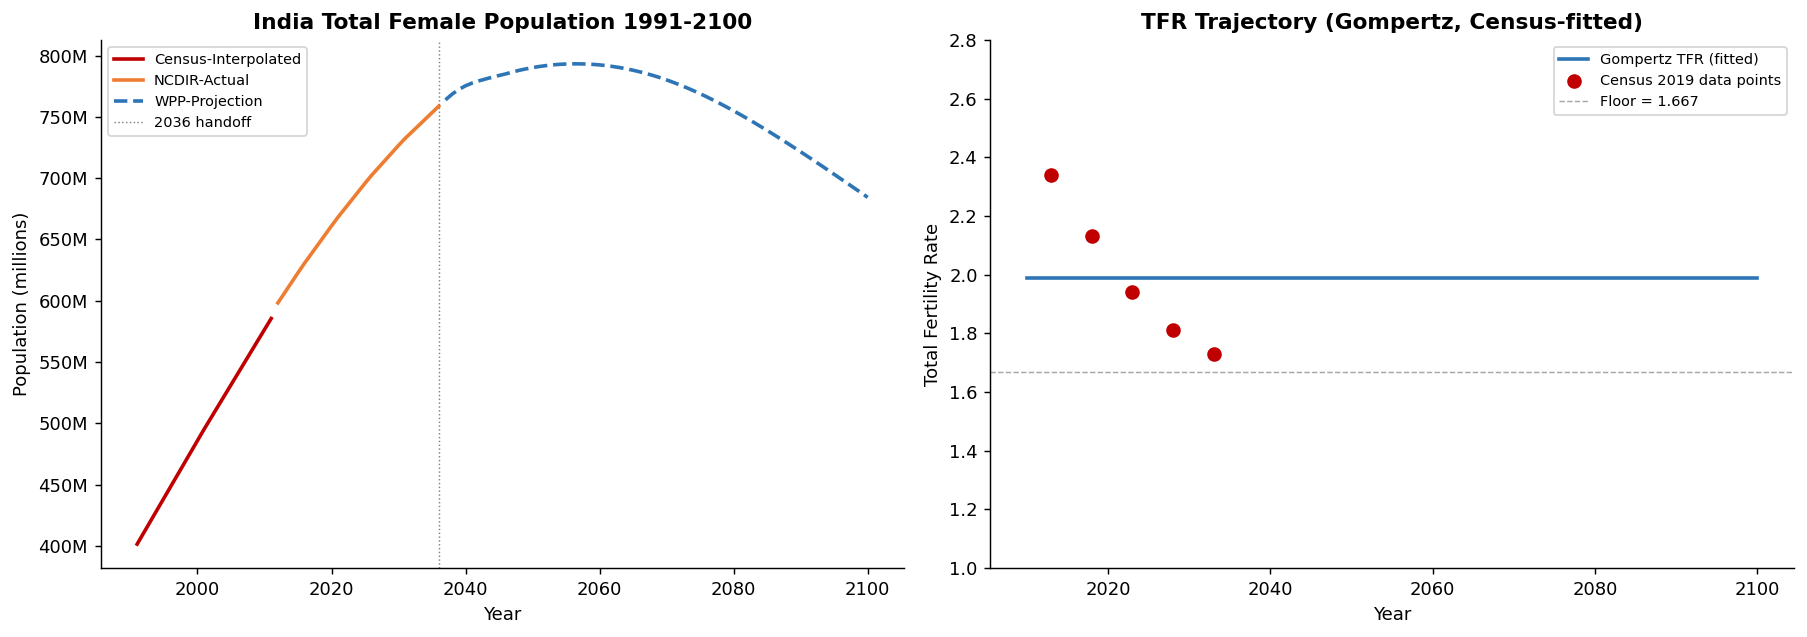


Validation: max |band_sum - Total| = 0.0000  (should be ~0)


In [12]:
# ── 9.1  India total population trajectory ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for src, color, ls in [
    ("Census-Interpolated", "#C00000", "-"),
    ("NCDIR-Actual",        "#ED7D31", "-"),
    ("WPP-Projection",      "#2E75B6", "--"),
]:
    sub = df_india[df_india["Source"] == src]
    ax.plot(sub["Year"], sub["Total"]/1e6, color=color, lw=2, ls=ls, label=src)
ax.axvline(2036, color="gray", lw=0.8, ls=":", label="2036 handoff")
ax.set_title("India Total Female Population 1991-2100", fontweight="bold")
ax.set_ylabel("Population (millions)")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}M"))
ax.legend(fontsize=8)

# ── 9.2  India TFR trajectory ────────────────────────────────────────────────
ax2 = axes[1]
yrs_plot = list(range(2010, 2101))
ax2.plot(yrs_plot, [tfr_proj(y) for y in yrs_plot], color="#2E75B6", lw=2,
         label="Gompertz TFR (fitted)")
ax2.scatter(census_yrs, census_tfr, color="#C00000", s=50, zorder=5,
            label="Census 2019 data points")
ax2.axhline(L_TFR, color="gray", lw=0.8, ls="--", alpha=0.7,
            label=f"Floor = {L_TFR}")
ax2.set_title("TFR Trajectory (Gompertz, Census-fitted)", fontweight="bold")
ax2.set_ylabel("Total Fertility Rate")
ax2.set_xlabel("Year")
ax2.legend(fontsize=8)
ax2.set_ylim(1.0, 2.8)

plt.tight_layout()
plt.show()

# ── 9.3  Band-sum vs Total check ─────────────────────────────────────────────
df_india["band_sum"] = df_india[BANDS].sum(axis=1)
max_err = (df_india["band_sum"] - df_india["Total"]).abs().max()
print(f"\nValidation: max |band_sum - Total| = {max_err:.4f}  (should be ~0)")


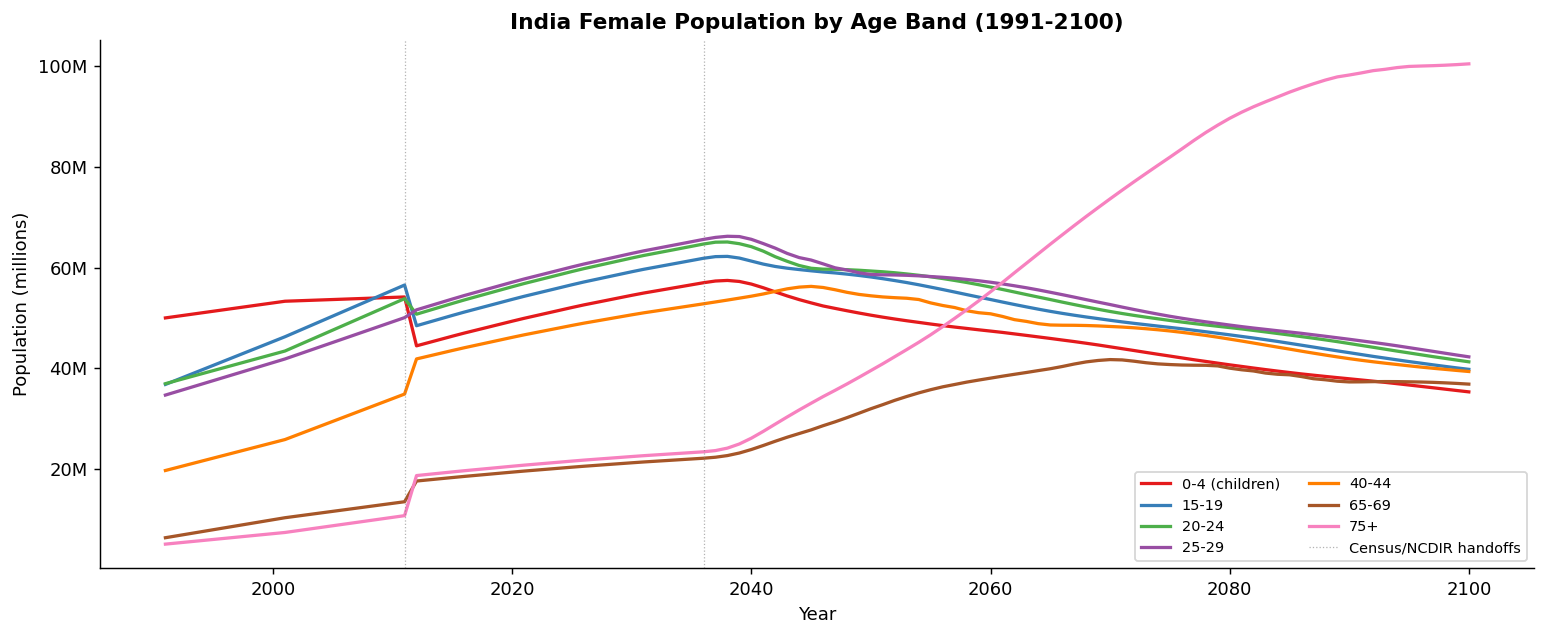

In [13]:
# ── 9.4  Selected age bands 1991-2100 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
HIGHLIGHT_BANDS = {
    "00-04": ("#e41a1c", "0-4 (children)"),
    "15-19": ("#377eb8", "15-19"),
    "20-24": ("#4daf4a", "20-24"),
    "25-29": ("#984ea3", "25-29"),
    "40-44": ("#ff7f00", "40-44"),
    "65-69": ("#a65628", "65-69"),
    "75+":   ("#f781bf", "75+"),
}
for band, (color, label) in HIGHLIGHT_BANDS.items():
    ax.plot(df_india["Year"], df_india[band]/1e6, color=color, lw=1.8, label=label)
ax.axvline(2011, color="gray", lw=0.7, ls=":", alpha=0.6)
ax.axvline(2036, color="gray", lw=0.7, ls=":", alpha=0.6, label="Census/NCDIR handoffs")
ax.set_title("India Female Population by Age Band (1991-2100)", fontweight="bold")
ax.set_ylabel("Population (millions)")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}M"))
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


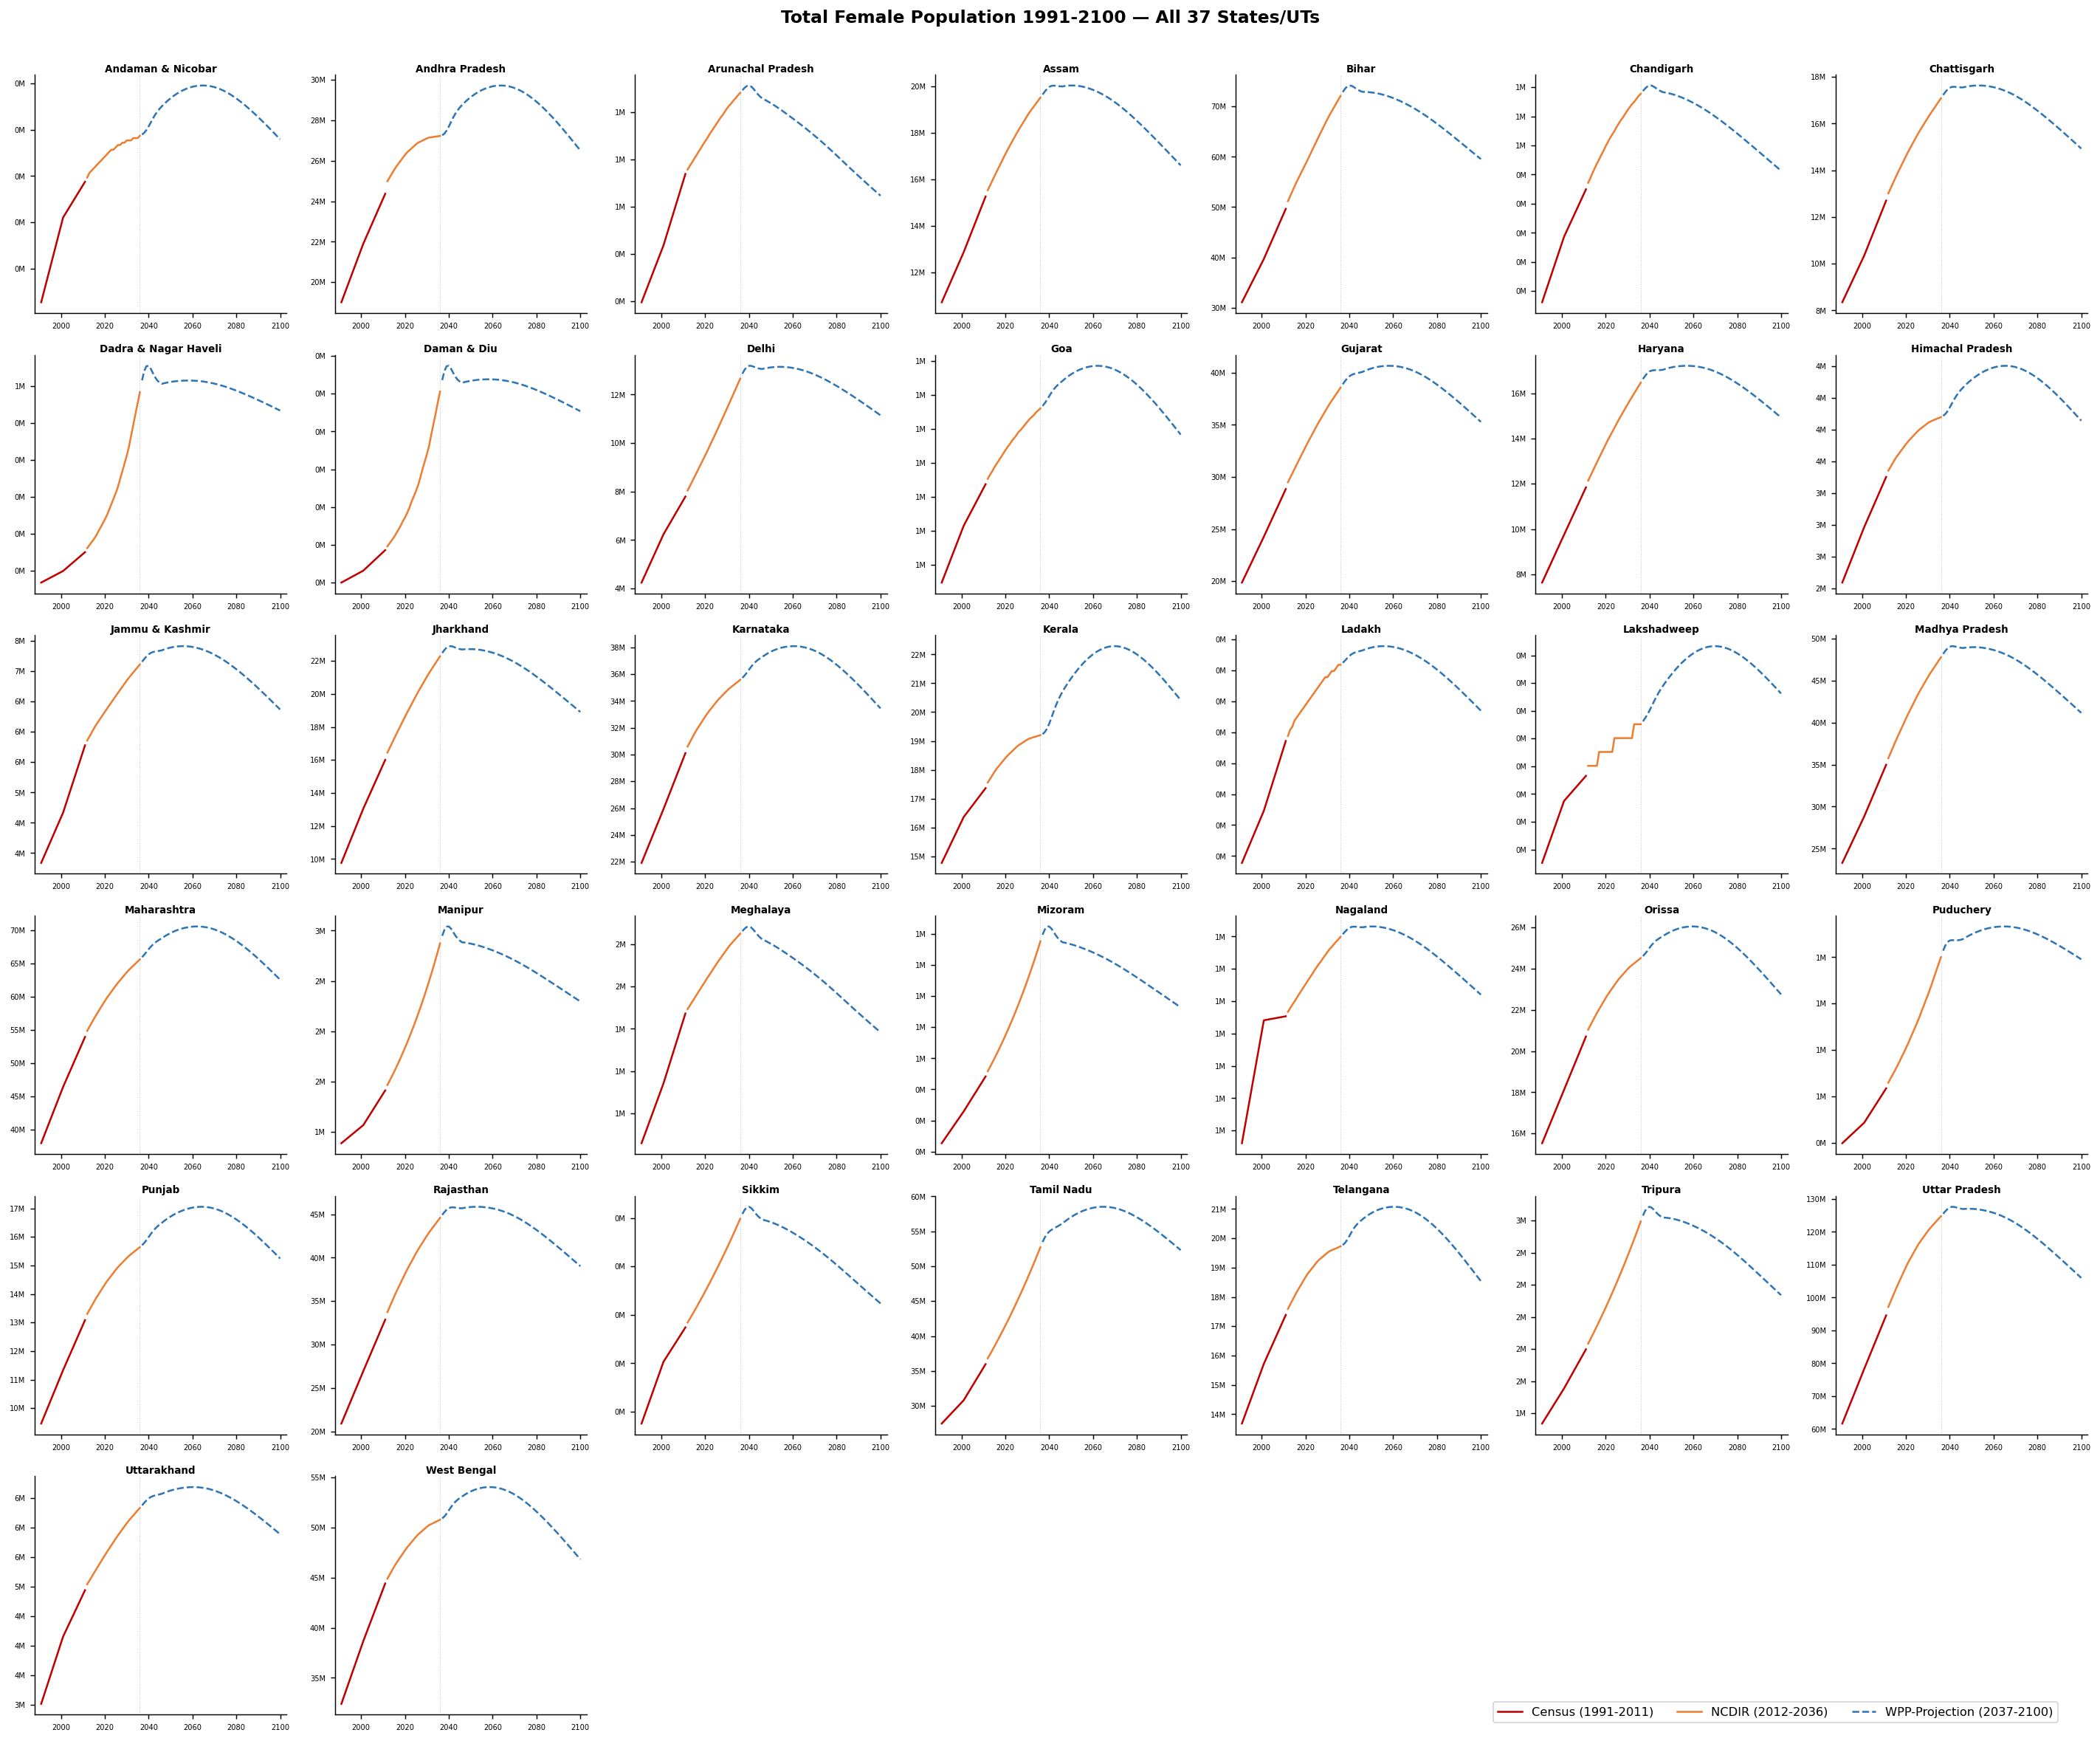


Core outputs written to the output/ directory.


In [14]:
# ── 9.5  All 37 states — total female population 1991-2100 ────────────────────
ncols, nrows = 7, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharey=False)
axes_flat = axes.flatten()

for i, state in enumerate(STATES):
    ax = axes_flat[i]
    df_s = to_df(state)
    for src, color, ls in [
        ("Census-Interpolated", "#C00000", "-"),
        ("NCDIR-Actual",        "#ED7D31", "-"),
        ("WPP-Projection",      "#2E75B6", "--"),
    ]:
        sub = df_s[df_s["Source"] == src]
        ax.plot(sub["Year"], sub["Total"]/1e6, color=color, lw=1.4, ls=ls)
    ax.axvline(2036, color="gray", lw=0.5, ls=":", alpha=0.5)
    ax.set_title(state, fontsize=7.5, fontweight="bold", pad=2)
    ax.tick_params(labelsize=5.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}M"))
    ax.set_xlim(1988, 2103)

for j in range(len(STATES), len(axes_flat)):
    axes_flat[j].set_visible(False)

handles = [
    plt.Line2D([0],[0], color="#C00000", lw=1.4, label="Census (1991-2011)"),
    plt.Line2D([0],[0], color="#ED7D31", lw=1.4, label="NCDIR (2012-2036)"),
    plt.Line2D([0],[0], color="#2E75B6", lw=1.4, ls="--", label="WPP-Projection (2037-2100)"),
]
fig.legend(handles=handles, loc="lower right", fontsize=9, ncol=3,
           bbox_to_anchor=(0.98, 0.01), frameon=True)
fig.suptitle("Total Female Population 1991-2100 — All 37 States/UTs",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

print("\nCore outputs written to the output/ directory.")


\
## Section 10: Custom Age Band Output

The 16 NCDIR bands are the native resolution of this dataset. Any other grouping
can be derived from them. This section provides a general tool for users to
specify arbitrary age ranges and get the corresponding population series.

### How it works

**Case 1 — Band aligns exactly with one or more NCDIR bands:**
The populations are summed directly.

$$P_{\text{custom}}(\text{start:end},\, y) = \sum_{x \;\subseteq\; [\text{start},\text{end}]} P(x,\, y)$$

**Case 2 — Band partially overlaps an NCDIR band (non-standard boundaries):**
UN WPP single-age data provides the within-band proportions.
For a custom range $[a, b]$ that partially overlaps NCDIR band $x = [\ell, u]$:

$$\phi(x,\, a, b,\, y) = \frac{\sum_{i=\max(a,\ell)}^{\min(b,u)} \text{WPP}_i(y)}{\sum_{i=\ell}^{u} \text{WPP}_i(y)}$$

$$P_{\text{custom}}(a{:}b,\, y) = \sum_{x} \phi(x,\, a, b,\, y) \times P(x,\, y)$$

**Example:** User wants `9-14` → NCDIR band `05-09` contributes $\phi = \text{WPP}_9 / \sum_{5}^{9}\text{WPP}_i$, band `10-14` contributes fully ($\phi = 1.0$).

### Configuration

Edit `USER_BANDS` in the next cell to specify your age ranges:
```python
USER_BANDS = [
    ("label",  start_age,  end_age),   # end_age=None means open-ended (includes 75+)
]
```


In [15]:
# ── 10.1  WPP fraction helper ─────────────────────────────────────────────────

def wpp_band_fraction(band, req_start, req_end, year):
    """
    Fraction of `band`'s population in ages [req_start, req_end].
    Uses WPP single-age data for the given year as the splitting key.
    Returns 1.0 if the requested range fully covers the band.
    Returns 0.0 if there is no overlap.
    """
    band_start, band_end = BAND_RANGES[band]
    ov_start = max(req_start, band_start)
    ov_end   = min(req_end,   band_end)

    if ov_start > ov_end:
        return 0.0   # no overlap
    if ov_start == band_start and ov_end == band_end:
        return 1.0   # full overlap — no WPP lookup needed

    yr = min(max(int(year), 1991), 2100)

    def wpp_age(a):
        col = "Age100+" if a >= 100 else f"Age{a}"
        return float(wpp_raw.loc[yr, col]) if col in wpp_raw.columns else 0.0

    numerator   = sum(wpp_age(a) for a in range(ov_start,   ov_end   + 1))
    denominator = sum(wpp_age(a) for a in range(band_start, band_end + 1))
    return numerator / denominator if denominator > 0 else 0.0


def compute_custom_bands(df_state, user_bands):
    """
    Compute user-defined age band totals from a state DataFrame.

    Parameters
    ----------
    df_state   : DataFrame with columns Year, [BANDS], Source
    user_bands : list of (label, start_age, end_age)
                 end_age=None means open-ended (includes all ages to 120+)

    Returns
    -------
    DataFrame with columns: State, Year, Source, <label for each user band>
    """
    rows = []
    for _, row in df_state.iterrows():
        yr   = int(row["Year"])
        out  = {"State": row["State"], "Year": yr, "Source": row["Source"]}
        for label, start, end in user_bands:
            end_eff = end if end is not None else 120
            total   = 0.0
            for band in BANDS:
                frac   = wpp_band_fraction(band, start, end_eff, yr)
                total += row[band] * frac
            out[label] = total
        rows.append(out)
    return pd.DataFrame(rows)


print("Custom band helpers defined.")
print("  wpp_band_fraction(band, start, end, year) — single-band WPP fraction")
print("  compute_custom_bands(df_state, user_bands) — full state DataFrame")


Custom band helpers defined.
  wpp_band_fraction(band, start, end, year) — single-band WPP fraction
  compute_custom_bands(df_state, user_bands) — full state DataFrame


In [16]:
# ── 10.2  User configuration — edit this cell ─────────────────────────────────
# Each entry: ("label", start_age, end_age)
# Use end_age=None for open-ended (75+ inclusive)
# Labels become column names in the output Excel.

USER_BANDS = [
    ("0-14",   0,  14),   # children
    ("15-29", 15,  29),   # young adults
    ("18-29", 18,  29),   # HPV-relevant: 18-29 (splits 15-17/18-19 boundary)
    ("30-64", 30,  64),   # working age
    ("65+",   65, None),  # older adults (65-74 + 75+)
    ("9-14",   9,  14),   # example: partial overlap with 05-09 band
]

# ── 10.3  Compute for India ───────────────────────────────────────────────────
df_custom_india = compute_custom_bands(df_india, USER_BANDS)
print("India custom bands (sample):")
print(df_custom_india[["Year","Source"] + [b[0] for b in USER_BANDS]].head(10).to_string(index=False))

# ── 10.4  Compute for all states ─────────────────────────────────────────────
custom_dfs = [df_custom_india]
for state in STATES:
    df_s = to_df(state)
    custom_dfs.append(compute_custom_bands(df_s, USER_BANDS))

df_custom_all = pd.concat(custom_dfs, ignore_index=True)

# ── 10.5  Export ──────────────────────────────────────────────────────────────
india_custom_out = os.path.join(OUT_DIR, "Custom_AgeBands_India.xlsx")
all_custom_out   = os.path.join(OUT_DIR, "Custom_AgeBands_All_States.xlsx")

df_custom_india.to_excel(india_custom_out, index=False)
df_custom_all.to_excel(all_custom_out, index=False)

print(f"\nSaved: {india_custom_out}")
print(f"Saved: {all_custom_out}  ({len(df_custom_all):,} rows)")
print("\nIndia '18-29' band at key years (millions):")
col_1829 = "18-29"
for yr in [2000, 2011, 2020, 2036, 2050, 2070, 2100]:
    row = df_custom_india[df_custom_india["Year"] == yr]
    if len(row):
        print(f"  {yr}: {row[col_1829].values[0]/1e6:.2f} M")


India custom bands (sample):
 Year              Source        0-14       15-29        18-29       30-64        65+         9-14
 1991 Census-Interpolated 150637216.0 108455007.0 8.584438e+07 125801816.0 16476176.0 5.702122e+07
 1992 Census-Interpolated 152985843.4 110767879.1 8.760198e+07 129680121.0 17320914.6 5.841110e+07
 1993 Census-Interpolated 155334470.8 113080751.2 8.939424e+07 133558426.0 18165653.2 5.985142e+07
 1994 Census-Interpolated 157683098.2 115393623.3 9.111491e+07 137436731.0 19010391.8 6.133157e+07
 1995 Census-Interpolated 160031725.6 117706495.4 9.285351e+07 141315036.0 19855130.4 6.275346e+07
 1996 Census-Interpolated 162380353.0 120019367.5 9.452777e+07 145193341.0 20699869.0 6.428767e+07
 1997 Census-Interpolated 164728980.4 122332239.6 9.615329e+07 149071646.0 21544607.6 6.565694e+07
 1998 Census-Interpolated 167077607.8 124645111.7 9.786414e+07 152949951.0 22389346.2 6.710288e+07
 1999 Census-Interpolated 169426235.2 126957983.8 9.966635e+07 156828256.0 23234

\
## Section 11: Lambda Function Generation for Epidemiological Models

In compartmental disease models (e.g., S → I → C → Deaths for HPV/cervical cancer),
the **force of infection** depends on the size of the age-specific susceptible pool.
Here, $\lambda(t)$ is the population of a user-chosen age band at simulation year $t$
(in thousands). It drives the transmission term in the ODE system.

### Two options

**Option 1 — Direct:**
$$\lambda_{\text{direct}}(t) = P_{\text{band}}(t)$$
Uses the population of the chosen band at the actual calendar year $t$.
Straightforward and interpretable; relies on the projected values for $t > 2036$.

**Option 2 — Shifted by $N$ years:**
$$\lambda_{\text{shifted}}(t) = P_{\text{band}}(t + N)$$
For simulation year $t$, uses the population value $N$ years ahead in calendar time.
This is useful when running a simulation from before 2012 (the NCDIR data window):
shifting by $N = 10$ means simulation year 2002 uses the 2012 population (reliable),
simulation year 2003 uses 2013, and so on — avoiding dependence on back-extrapolated
pre-2012 values entirely.

### Configuration

Edit the three variables below:
```python
LAMBDA_BAND  = "18-29"   # label from USER_BANDS (Section 10)
N_SHIFT      = 10        # years to shift for Option 2
LAMBDA_YEARS = range(2002, 2071)   # simulation time window
```

The outputs (`Lambda_Direct`, `Lambda_Shifted`) are exported as a CSV that can be
loaded directly into any epidemiological model script.


Saved: /Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections/output/Lambda_18_29.csv

Band: 18-29  |  N_SHIFT = 10  |  years 2002–2070

    Year    Direct (k)   Shifted (k)
    2002     105,439.1       121,536.6
    2005     112,493.3       126,649.1
    2010     123,988.5       134,772.1
    2012     121,536.6       137,972.1
    2020     134,772.1       148,736.0
    2036     155,329.1       144,146.8
    2050     141,372.0       134,966.4
    2070     123,921.9       115,482.9


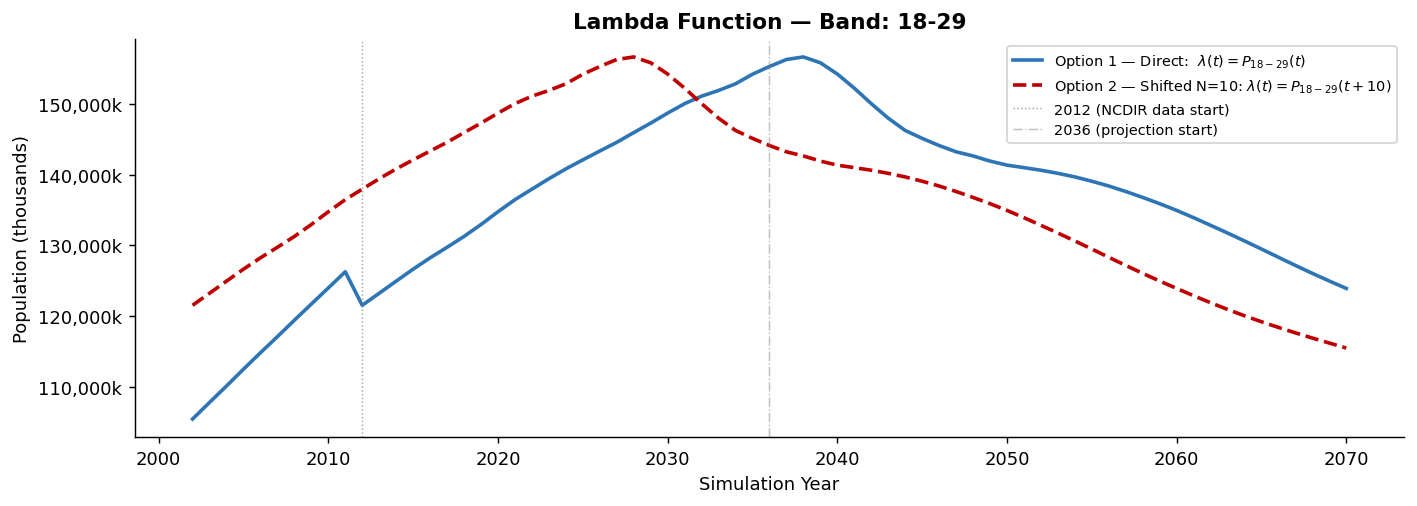


Lambda arrays are ready for use in your epidemiological model.
Load via:  pd.read_csv('/Users/arvinth/Documents/Nirav Bhat DDP/DDP/india-female-pop-projections/output/Lambda_18_29.csv')


In [17]:
# ── 11.1  User configuration ─────────────────────────────────────────────────
LAMBDA_BAND  = "18-29"              # must be one of the labels in USER_BANDS
N_SHIFT      = 10                   # years to shift for Option 2
LAMBDA_YEARS = list(range(2002, 2071))  # simulation time window

# ── 11.2  Validate band selection ────────────────────────────────────────────
band_labels = [b[0] for b in USER_BANDS]
if LAMBDA_BAND not in band_labels:
    raise ValueError(
        f"'{LAMBDA_BAND}' not found in USER_BANDS.\n"
        f"Available labels: {band_labels}\n"
        f"Update LAMBDA_BAND or add the band to USER_BANDS in Section 10."
    )

# ── 11.3  Build lookup: year -> population (thousands) ───────────────────────
# df_custom_india was produced in Section 10 in absolute persons.
lambda_lookup = dict(zip(
    df_custom_india["Year"].astype(int),
    df_custom_india[LAMBDA_BAND] / 1e3    # persons → thousands
))

# ── 11.4  Generate Option 1 (Direct) and Option 2 (Shifted) ──────────────────
lambda_direct  = np.array([lambda_lookup.get(t,          np.nan) for t in LAMBDA_YEARS])
lambda_shifted = np.array([lambda_lookup.get(t + N_SHIFT, np.nan) for t in LAMBDA_YEARS])

n_missing_direct  = int(np.sum(np.isnan(lambda_direct)))
n_missing_shifted = int(np.sum(np.isnan(lambda_shifted)))
if n_missing_direct > 0:
    print(f"WARNING: {n_missing_direct} years in LAMBDA_YEARS fall outside 1991-2100 "
          f"(will be NaN in Option 1). Adjust LAMBDA_YEARS or LAMBDA_BAND.")
if n_missing_shifted > 0:
    print(f"WARNING: {n_missing_shifted} years in LAMBDA_YEARS + N_SHIFT fall outside "
          f"1991-2100 (will be NaN in Option 2).")

# ── 11.5  Assemble and export ─────────────────────────────────────────────────
df_lambda = pd.DataFrame({
    "Year":                        LAMBDA_YEARS,
    "Lambda_Direct":               lambda_direct,
    f"Lambda_Shifted_N{N_SHIFT}":  lambda_shifted,
})
lambda_out = os.path.join(OUT_DIR, f"Lambda_{LAMBDA_BAND.replace('-','_')}.csv")
df_lambda.to_csv(lambda_out, index=False)
print(f"Saved: {lambda_out}")
print(f"\nBand: {LAMBDA_BAND}  |  N_SHIFT = {N_SHIFT}  |  years {LAMBDA_YEARS[0]}–{LAMBDA_YEARS[-1]}")
print(f"\n  {'Year':>6}  {'Direct (k)':>12}  {'Shifted (k)':>12}")
for _, row in df_lambda[df_lambda["Year"].isin([2002, 2005, 2010, 2012, 2020, 2036, 2050, 2070])].iterrows():
    print(f"  {int(row['Year']):>6}  {row['Lambda_Direct']:>12,.1f}  "
          f"  {row[f'Lambda_Shifted_N{N_SHIFT}']:>12,.1f}")

# ── 11.6  Plot both options ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(LAMBDA_YEARS, lambda_direct,  color="#2E75B6", lw=2,
        label=f"Option 1 — Direct:  $\\lambda(t) = P_{{{LAMBDA_BAND}}}(t)$")
ax.plot(LAMBDA_YEARS, lambda_shifted, color="#C00000", lw=2, ls="--",
        label=f"Option 2 — Shifted N={N_SHIFT}: $\\lambda(t) = P_{{{LAMBDA_BAND}}}(t+{N_SHIFT})$")
ax.axvline(2012, color="gray", lw=0.8, ls=":", alpha=0.7, label="2012 (NCDIR data start)")
ax.axvline(2036, color="gray", lw=0.8, ls="-.", alpha=0.5, label="2036 (projection start)")
ax.set_title(f"Lambda Function — Band: {LAMBDA_BAND}", fontweight="bold")
ax.set_xlabel("Simulation Year")
ax.set_ylabel("Population (thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}k"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nLambda arrays are ready for use in your epidemiological model.")
print(f"Load via:  pd.read_csv('{lambda_out}')")
